Testing loading data with io.py

In [1]:
from methane_noise_forcing import io
from hydra import compose, initialize
import matplotlib.pyplot as plt

In [2]:
with initialize(version_base=None, config_path="../../configs"):  # configs with data paths
    cfg = compose(config_name="config")
data = {}

In [3]:
## mitchell 2013
data["wdc05a"] = io.load_mitchell2013(**cfg.io.wdc05a)
data["wdc06a"] = io.load_mitchell2013(**cfg.io.wdc06a)
data["gisp2"] = io.load_mitchell2013(**cfg.io.gisp2)

## rhodes 2013 (rhodesandbrook2019)
data["neem"] = io.load_rhodesandbrook2019(**cfg.io.neem)

In [4]:
data["wdc06a"]

,gas_age,ch4
0,1780.7,729.443791
1,1771.2,727.536987
2,1763.2,716.804587
3,1754.1,712.619510
4,1745.5,704.187930
...,...,...
384,-2568.9,576.783533
385,-2609.5,581.987181
386,-2662.2,576.631691
387,-2703.0,574.002950


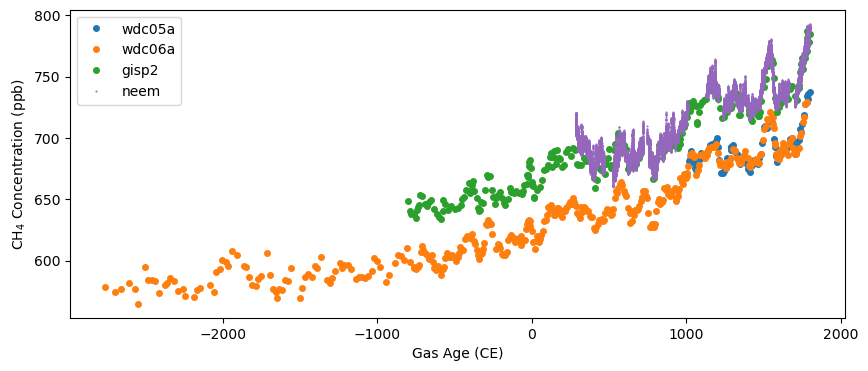

In [8]:
## plot data
plot_kwargs = {
    "marker": "o",
    "linestyle": "None",
}
colors = {
    "wdc05a": "tab:blue",
    "wdc06a": "tab:orange",
    "gisp2": "tab:green",
    "neem": "tab:purple",
}

fig, ax = plt.subplots(figsize=(10, 4))
for key, df in data.items():
    if key == "neem":
        markersize = 0.5
    else:
        markersize = 4
    ax.plot(df["gas_age"], df["ch4"], label=key, color=colors[key], markersize=markersize, **plot_kwargs)

ax.set_xlabel("Gas Age (CE)")
ax.set_ylabel("CH$_4$ Concentration (ppb)")
ax.legend()